Name: MW\
Date: 2023-12-12\
Proj: mwii_analysis\
Inputs: throwing knife csv\
Outputs: exploratory plots

---

#### 1. Setup environment

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

#### 2. Import data

In [8]:
# Read in csv file
mwii_dat = pd.read_csv("../data/mw2022_data.csv") # since the csv is in another directory, that must be specified

#### 3. Tidy data
Imported data is already in a tidy format

#### 4. Explore

<Axes: xlabel='Kills'>

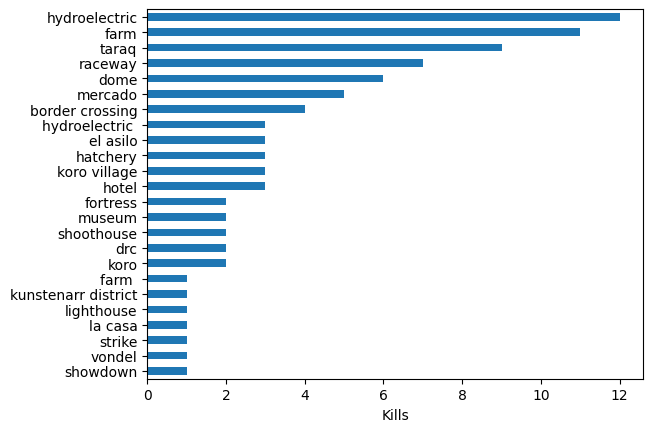

In [30]:
# Count the number of map occurrences and plot as a histogram

mwii_dat["map"].value_counts().sort_values(ascending = True).plot(kind = "barh",
                                                                  ylabel = "",
                                                                  xlabel = "Kills")


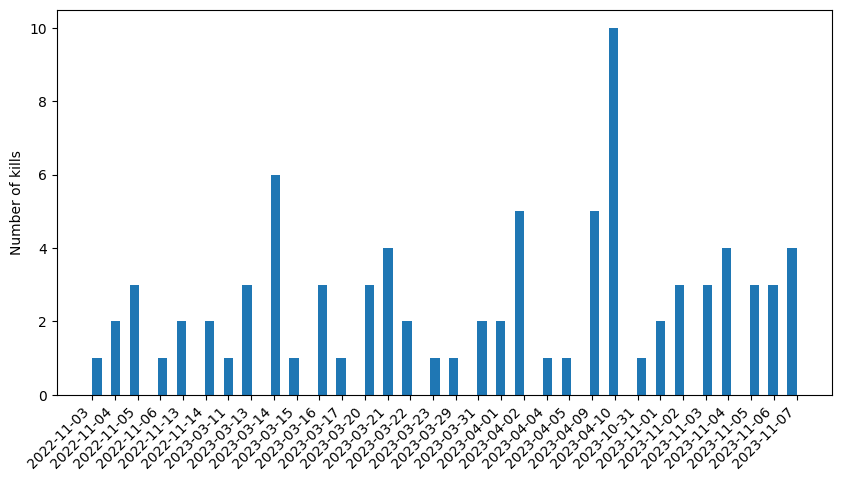

In [29]:
# Display a date histogram (cumulative sum of date occurrences on x-axis)
plt.figure(figsize = (10, 5))
plt.hist(mwii_dat["date"], bins = 75)
plt.xlabel("")
plt.xticks(ha = "right", rotation = 45) 
plt.ylabel("Number of kills")
plt.show()


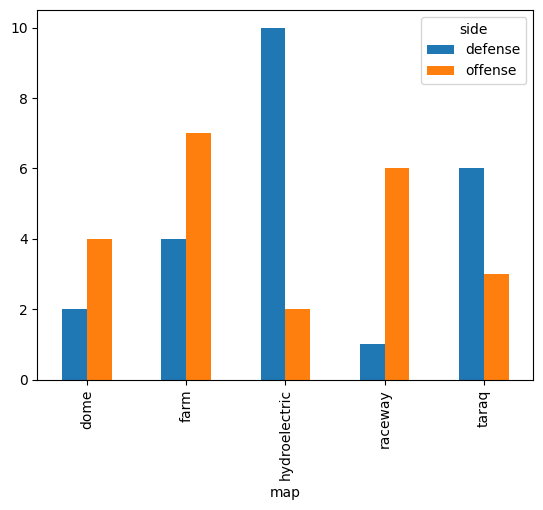

In [21]:
# Look at offense versus defense at a coarse scale

mwii_dat["side"].value_counts() # very balanced; 44 hits on defense and 42 on offense across all maps

# Look at the maps that accounted for ~50% of the hits and speculate/explain why these had higher occurrences than others

mwii_dat["map"].value_counts() # hydroelectric, farm, taraq, raceway and dome account for 53% of the hits

# Subset the top five maps and take a deeper look

top5_maps = mwii_dat[mwii_dat["map"].isin(["hydroelectric", "farm", "taraq", "raceway", "dome"])]

# Make a bar chart with hits on y-axis, maps on x-axis and two bars for each map (offense and defense)

ax = top5_maps.groupby(['map']).side.value_counts().reset_index(name = 'counts').pivot(index = 'map', columns = 'side', values = 'counts').plot(kind = 'bar')

In [27]:
# Check out the player names - is there anything interesting?

mwii_dat.player.value_counts()

# Pull out the players that were hit more than once

top_players = mwii_dat[mwii_dat["player"].isin(["ToXiC_Lucifer", "bevyq", "AZN", "JonnyDoucher_94_"])]

top_players

,map,date,side,player
13,taraq,2023-03-13,defense,JonnyDoucher_94_
14,taraq,2023-03-13,defense,JonnyDoucher_94_
41,raceway,2023-04-02,offense,ToXiC_Lucifer
42,raceway,2023-04-02,offense,ToXiC_Lucifer
43,raceway,2023-04-02,offense,ToXiC_Lucifer
56,hotel,2023-04-10,offense,AZN
57,hotel,2023-04-10,defense,AZN
58,raceway,2023-04-10,offense,bevyq
59,raceway,2023-04-10,offense,bevyq
